# BayesFlow: Personwise Model Comparison (Mammals)

Author:      David Izydorczyk 

Last Update: 03.06.2025

Reminder: Install new packages with `python3.11 -m pip install package`  | active environemnt `.\personwise_BF\Scripts\activate`

In [1]:
import numpy as np
import numpy.random as rng


import matplotlib.pyplot as plt
import seaborn as sns


import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "jax"

import keras
import bayesflow as bf
import pandas as pd
import statsmodels.formula.api as sm



from plotnine import (
    theme_set,
    theme_bw
)
theme_set(theme_bw())


INFO:bayesflow:Using backend 'jax'


In [2]:
import utils.helper_functions as fn
import utils.model_functions as mf

# makes sure mf is loaded correctly
import importlib
importlib.reload(mf) 
importlib.reload(fn) 

<module 'utils.helper_functions' from 'c:\\Users\\dizydorc\\OneDrive\\University\\Project Github Repositories\\Estimation processes in real-world domains\\Scripts\\Model Comparison\\utils\\helper_functions.py'>

In [3]:
# avoid scientific notation for outputs
np.set_printoptions(suppress=True)

# 1 Load Design Data 

In [4]:
df = pd.read_csv('..\..\Materials\design_data_countries.csv', sep=';',decimal=",")
df.head()

,ID,item,crit,img,training,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,1,China,78.0,c_1.png,0,-0.195778,0.351923,-0.148973,0.491947,0.360079,-0.111224,-0.218835,-0.208312,-0.266885,-0.010970
1,2,India,72.2,c_2.png,0,0.032878,0.320295,-0.119975,0.440877,0.412641,0.111823,-0.039848,0.129529,-0.212480,-0.295115
2,3,United States,79.5,c_3.png,0,-0.528393,-0.058237,0.048887,-0.207149,0.237762,0.456765,-0.154473,-0.124991,-0.205178,0.055065
3,4,Nigeria,54.6,c_4.png,1,0.456581,0.437979,-0.053559,-0.379797,0.075443,0.100560,0.006092,-0.008254,-0.136478,0.032607
4,5,Brazil,76.0,c_5.png,0,-0.025939,-0.363749,-0.445680,-0.121966,0.104104,0.046055,-0.129026,0.135959,-0.073909,0.040447


In [5]:
all_cues = df[[f'V{i}' for i in range(1, 11)]].to_numpy(dtype=float)
all_crit = df[['crit']].to_numpy(dtype=float).flatten()

# Get Exemplar Set 
exemplars = df.loc[df['training'] == 1,:] 
ex_cues   = exemplars[[f'V{i}' for i in range(1, 11)]].to_numpy(dtype=float)
ex_crit   = exemplars[['crit']].to_numpy(dtype=float).flatten()
ex_IDs    = exemplars[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Get Data from only Testing items
testing = df.loc[df['training'] == 0,:]

# Get the IDs
test_IDs = testing[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Extract cues of the testing stimuli
cues     = testing[[f'V{i}' for i in range(1, 11)]].to_numpy(dtype=float)

# Make cue dictionary
dict_cues = {f"cue_{i}": cues[:, i] for i in range(cues.shape[1])}

# Geet number of trials and number of dimensions
n_trials, n_dim     = cues.shape

print("n_trials:", n_trials)
print("n_dim:"   , n_dim)

n_trials: 68
n_dim: 10


In [6]:
# Set general parameters
rate = 0.25

In [7]:
position_encodings = np.linspace(0, 1, n_trials, dtype=np.float32)

# 2 Define Models

## 2.1 CAM - Cue Abstraction (Rule) Model 

In [8]:
# Run Regression on whole item samples
result = sm.ols(formula="crit ~ V1 + V2 + V3 + V4 + V5 + V6 + V7 + V8 + V9 + V10", data=df).fit()
# print(result.params)
# print(result.summary())

In [9]:
def prior_CAM(n_dim = n_dim, rate = rate):

    # Init weight parameters
    w = np.zeros(n_dim+1)

    # Intercept
    w[0]   = rng.normal(73.32, 15)

    # Dimension weights (Importance)
    w[1:]  = rng.normal(0, 15, size = n_dim)

    sigma  = rng.exponential(1/rate)

    return dict(w=w, sigma=sigma)

In [10]:
def model_CAM(w, sigma, cues=cues, p=position_encodings):

    n_trials, _   = cues.shape
  
    # Pre-allocate the output matrix
    pred_crit = mf.CAM_experiment(w,cues)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)
    
    return dict(x=x, p=p)  


In [11]:
simulator_CAM = bf.make_simulator([prior_CAM, model_CAM])

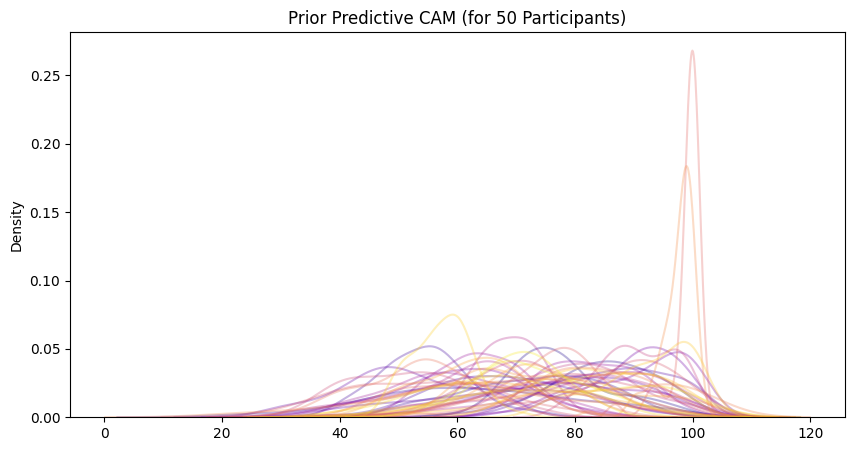

In [12]:
fig, ax = fn.plot_prior_predictives(simulator_CAM, "CAM")

## 2.2 GCM - Exemplar Model


In [13]:
def prior_GCM(n_dim = n_dim, rate = rate):

    c      = rng.exponential(1/0.1)
    w      = rng.dirichlet(np.ones(n_dim), size = 1)*n_dim  
    sigma  = rng.exponential(1/rate)

    return dict(c=c, w=w.squeeze(), sigma=sigma)

In [14]:
def model_GCM(c, w, sigma, cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
  
    n_trials = cues.shape[0]

    # Make predictions based on the GCM model for all trials at once
    pred_crit = mf.GCM_experiment(cues, ex_cues, ex_crit, w, c)

    # Simulate responses
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)

    return dict(x=x,p=p)

In [15]:
simulator_GCM = bf.make_simulator([prior_GCM, model_GCM])

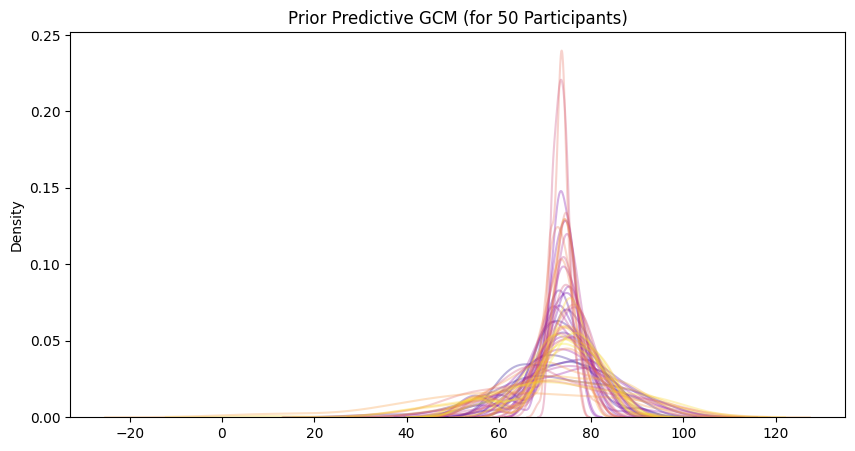

In [16]:
fig, ax = fn.plot_prior_predictives(simulator_GCM, "GCM")

## 2.3 RulExJ Model


In [17]:
def prior_RULEXJ(n_dim = n_dim, rate = rate):

    # Rule part
    CAM_pars = prior_CAM(n_dim = n_dim, rate = rate)

    # Exemplar part
    GCM_pars = prior_GCM(n_dim = n_dim, rate = rate)

    # Blending
    a        = rng.uniform(0,1)

    return dict(alpha = a, w_CAM=CAM_pars["w"], c = GCM_pars["c"], w_GCM = GCM_pars["w"], sigma=CAM_pars["sigma"])

In [18]:
def model_RULEXJ(alpha, w_CAM, c, w_GCM, sigma,  cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
    
    n_trials, _   = cues.shape
    
    pred_CAM = mf.CAM_experiment(w_CAM,cues)

    pred_GCM = mf.GCM_experiment(cues, ex_cues, ex_crit,w_GCM,c)

    pred_RULEXJ = alpha*pred_CAM + (1-alpha)*pred_GCM

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_RULEXJ, sd=sigma, low=0, upp=100, size=n_trials)

    return dict(x=x,p=p)

In [19]:
simulator_RULEXJ = bf.make_simulator([prior_RULEXJ, model_RULEXJ])

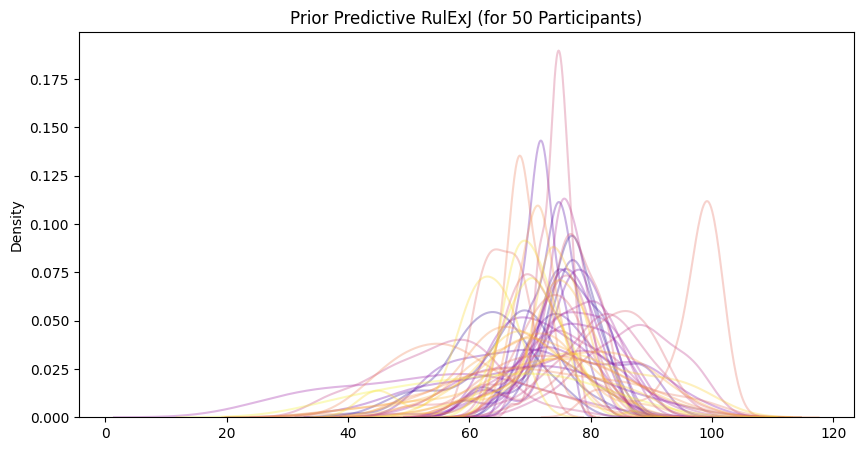

In [20]:
fig, ax = fn.plot_prior_predictives(simulator_RULEXJ, "RulExJ")

## 2.4 Mapping Model (MAPP)

For the mapping model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion.

In [21]:
# Change cue direction and redefine exemplar and stimuli cues for the mapping model
all_mapp_cues  = mf.preprocess_cues(all_cues,all_crit)
ex_mapp_cues   = all_mapp_cues[ex_IDs-1,:]
mapp_cues      = all_mapp_cues[test_IDs-1,:]
dict_mapp_cues = {f"cue_{i}": mapp_cues[:, i] for i in range(mapp_cues.shape[1])}

In [22]:
def prior_MAPP(lower = 2, upper = 12, rate = rate):

    n_cats = fn.truncated_poisson_np(5, lower = lower, upper = upper)
    sigma  = rng.exponential(1/rate)
    
    return  dict(n_cats=n_cats[0], sigma=sigma)

In [23]:
def model_MAPP(n_cats, sigma, cues=mapp_cues,ex_cues=ex_mapp_cues, ex_crit=ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    # Make predictions based on the GCM model for each person
    pred_crit = mf.MAPP_experiment(n_cats,cues,ex_cues,ex_crit)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=100, size=n_trials)
  

    return dict(x=x,p=p)

In [24]:
simulator_MAPP = bf.make_simulator([prior_MAPP, model_MAPP])

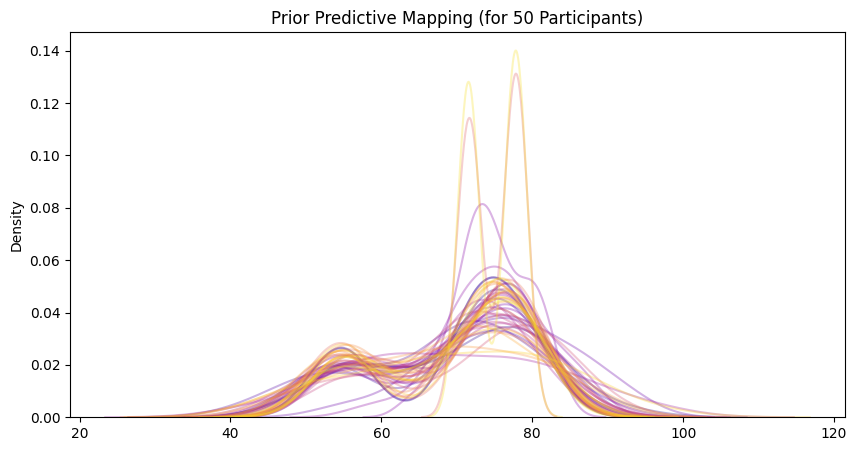

In [25]:
fig, ax = fn.plot_prior_predictives(simulator_MAPP, "Mapping")

## 2.5 QuickEst

For the QuickEst-Model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion. Also the cues need to binary.

In [26]:
# Change cue direction and redefine exemplar and stimuli cues for the QuickEst model
all_QEst_cues  = mf.preprocess_cues_QuickEst(all_cues,all_crit)
ex_QEst_cues   = all_QEst_cues[ex_IDs-1,:]
QEst_cues      = all_QEst_cues[test_IDs-1,:]
dict_QEst_cues = {f"cue_{i}": QEst_cues[:, i] for i in range(QEst_cues.shape[1])}

In [27]:
def prior_QEst():

    sigma = fn.truncated_cauchy_np(loc=0, scale=10, lower=0.001, upper=100, size=1)

    return dict(sigma=sigma)

In [28]:
def model_QEst(sigma,  cues = QEst_cues, ex_cues = ex_QEst_cues, ex_crit = ex_crit, p=position_encodings):
 
    # Step 0: Draw "memorized" ex_crit for each participant
    mem_ex_crit = np.random.normal(ex_crit,sigma) 

    # Make predictions based on the GCM model for each person
    x = mf.QuickEst_experiment(cues,ex_cues,mem_ex_crit)
 

    return dict(x = np.clip(x, 0, 100),p=p)

In [29]:
simulator_QEst = bf.make_simulator([prior_QEst, model_QEst])

c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\Scripts\Model Comparison\utils\helper_functions.py:127: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\Scripts\Model Comparison\utils\helper_functions.py:127: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\Scripts\Model Comparison\utils\helper_functions.py:127: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
c:\Users\dizydorc\OneDrive\University\Project Github Repositories\Estimation processes in real-world domains\Scripts\Model Comparison\utils\helper_functions.

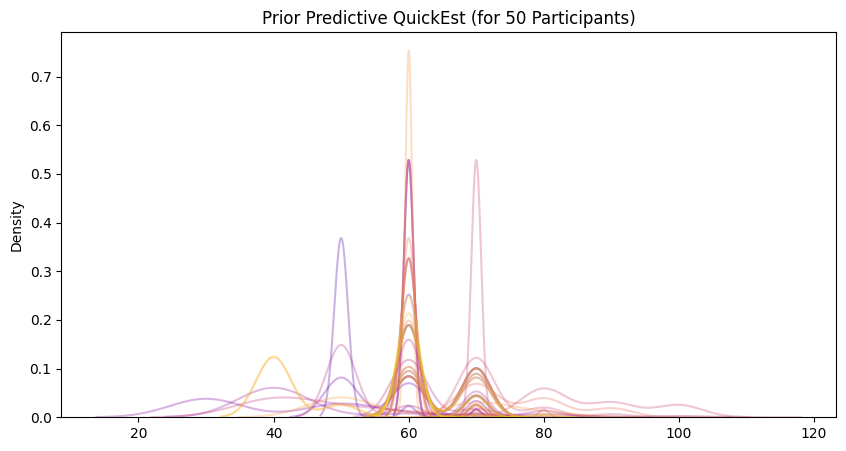

In [30]:
fig, ax = fn.plot_prior_predictives(simulator_QEst, "QuickEst")

## 2.6 RGuess - Random Guessing 

In [31]:
def prior_RGuess():

    sigma_range = rng.exponential(1/0.25, size = 1)

    return  dict(sigma_range=sigma_range)

In [32]:
def model_RGuess(sigma_range, cues = cues, ex_crit = ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    min_observed_crit = rng.normal(np.min(ex_crit),sigma_range)
    range_width = max(0.01, rng.normal(np.max(ex_crit) - np.min(ex_crit), sigma_range))  # enforce positive width

    max_observed_crit = min_observed_crit + abs(range_width)

    x =  rng.uniform(min_observed_crit, max_observed_crit, size = n_trials)
    
    return dict(x = np.clip(x, 0, 100),p=p)


In [33]:
simulator_RGuess = bf.make_simulator([prior_RGuess, model_RGuess])

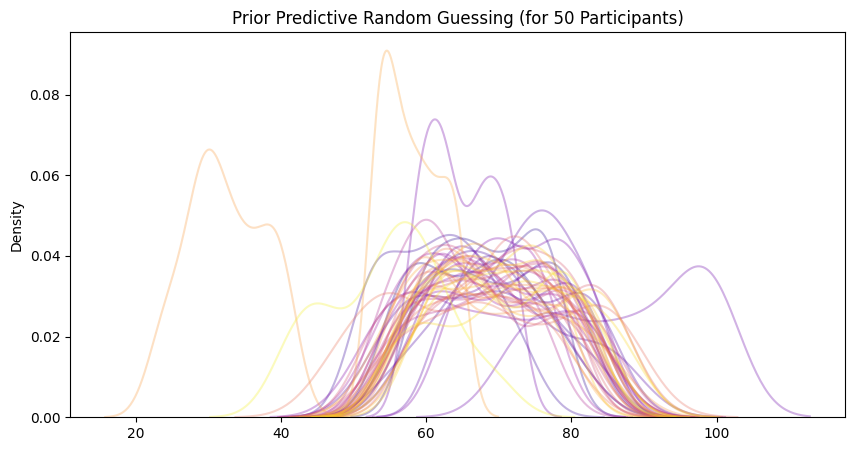

In [34]:
fig, ax = fn.plot_prior_predictives(simulator_RGuess, "Random Guessing")

# 3 Training Networks

In [35]:
simulator = bf.simulators.ModelComparisonSimulator(
    simulators        = [simulator_RULEXJ,simulator_CAM,simulator_GCM,simulator_MAPP,simulator_QEst,simulator_RGuess],
    use_mixed_batches = True
)

In [36]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")   
    .as_time_series(["x","p"])
    .standardize("x")
    .drop(["alpha","c","sigma","w_GCM","w_CAM","n_cats","sigma_range"])
    .concatenate(["x", "p"], into="summary_variables")

)

summary_network    = bf.networks.TimeSeriesNetwork(summary_dim=20)

classifier_network = bf.networks.MLP(widths=[256] * 32, activation="silu", dropout=None)

approximator = bf.approximators.ModelComparisonApproximator(
     num_models         = 6,
     classifier_network = classifier_network,
     summary_network    = summary_network,
     adapter            = adapter,
 )

In [ ]:
num_batches_per_epoch = 512
batch_size            = 64
epochs                = 100

learning_rate = keras.optimizers.schedules.CosineDecay(1e-4, decay_steps=epochs * num_batches_per_epoch)
optimizer     = keras.optimizers.Adam(learning_rate=learning_rate)
approximator.compile(optimizer=optimizer)

In [38]:
%%time

history = approximator.fit(epochs = epochs, batch_size = batch_size,  num_batches = num_batches_per_epoch, adapter = adapter, simulator = simulator)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Incompatible simulator output. The following keys will be dropped: alpha, c, n_cats, sigma, sigma_range, w, w_CAM, w_GCM.


Epoch 1/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - loss: 38.7189 - loss/classifier_loss: 38.7189
Epoch 2/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 5.5692 - loss/classifier_loss: 5.5692
Epoch 3/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 2.9059 - loss/classifier_loss: 2.9059
Epoch 4/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 1.8430 - loss/classifier_loss: 1.8430
Epoch 5/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 1.4917 - loss/classifier_loss: 1.4917
Epoch 6/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 1.3701 - loss/classifier_loss: 1.3701
Epoch 7/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 1.1902 - loss/classifier_loss: 1.1902
Epoch 8/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 1.1558 - loss/classifier_loss: 1.1558
Epoch 9/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - loss: 1.0349 - loss/classifier_loss: 1.0349
Epoch 10/128
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - loss: 1.0311 - loss/classifier_

In [41]:
df          = simulator.sample(10000)
pred_models = approximator.predict(conditions=df)

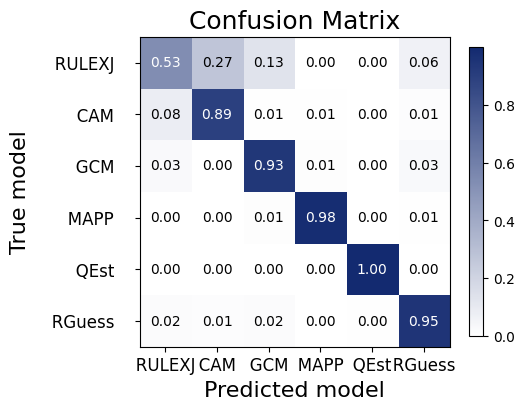

In [42]:
f=bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=df["model_indices"],
    normalize="true",
    model_names=["   RULEXJ   ", "   CAM   ", "   GCM   ", "   MAPP   ", "   QEst   ", "   RGuess   "]
)

In [43]:
# Save model
approximator.save("..\..\Results\model_comparison_COUNTRIES.keras")

# 4 Model Fitting per Participant

In [44]:
# Load data
df = pd.read_csv('..\..\Data\data_analysis_countries.csv', sep = ",")
df.head()

,ID_item,item,img,training,crit,n11xewpgbxj4,munr1sh9ezc8,7k1k3a6issm1,4n5e6nkj21xl,k5d1wxxqlmni,...,1nziths5mtj0,oi136bu0srj9,i6xr02yzsoee,8pxa6oh4ylfk,5p4nqbumcod1,nxibx285n3rn,kesc2p7oa7me,okeobbnlodto,sbydcgc89frj,vzgw3yufjpr4
0,1,China,c_1.png,0,78.0,69,76.0,70,80.0,84,...,85,79,79.8,76.4,79,80,80.0,79,82.0,76.0
1,2,India,c_2.png,0,72.2,68,76.0,70,70.0,60,...,70,74,73.0,79.9,72,72,72.0,67,87.0,70.0
2,3,United States,c_3.png,0,79.5,69,78.0,83,80.0,74,...,75,80,82.0,84.5,86,82,80.0,76,76.0,NaN
3,4,Nigeria,c_4.png,1,54.6,74,53.6,54,54.0,56,...,53,55,54.6,54.2,71,54,53.6,64,54.6,70.0
4,5,Brazil,c_5.png,0,76.0,77,70.0,80,65.0,74,...,82,77,78.0,74.6,79,80,75.0,76,79.0,70.0


In [45]:
# Replace the NaNs with the row means calculated across all other participants (i.e., exclude the NaN and the participant with the NaN from the mean)
# Sample: assuming df is your original DataFrame

meta_cols     = ['ID_item', 'item', 'img', 'training', 'crit']
response_cols = [col for col in df.columns if col not in meta_cols]

# Copy metadata to preserve original
meta_df   = df[meta_cols].copy()
responses = df[response_cols].copy()

# Function to replace NaNs with mean of other participants
def replace_nan_with_row_mean_except_self(row):
    for col in row.index:
        if pd.isna(row[col]):
            # Compute mean of the row excluding the NaN and this column
            other_values = row.drop(labels=col).dropna()
            if not other_values.empty:
                row[col] = other_values.mean()
    return row

# Apply the function row-wise
responses_filled = responses.apply(replace_nan_with_row_mean_except_self, axis=1)

# Combine with metadata
df_filled = pd.concat([meta_df, responses_filled], axis=1)

In [46]:
data            = df_filled.to_numpy()
data            = np.float32(data[(test_IDs-1),5:])

n_trials, n_sub = data.shape

print("n_trials:", n_trials)
print("n_sub:"   , n_sub)

n_trials: 68
n_sub: 48


## Plot data

Text(0.5, 1.0, 'Prior Predictive: Guessing (for 100 Participants)')

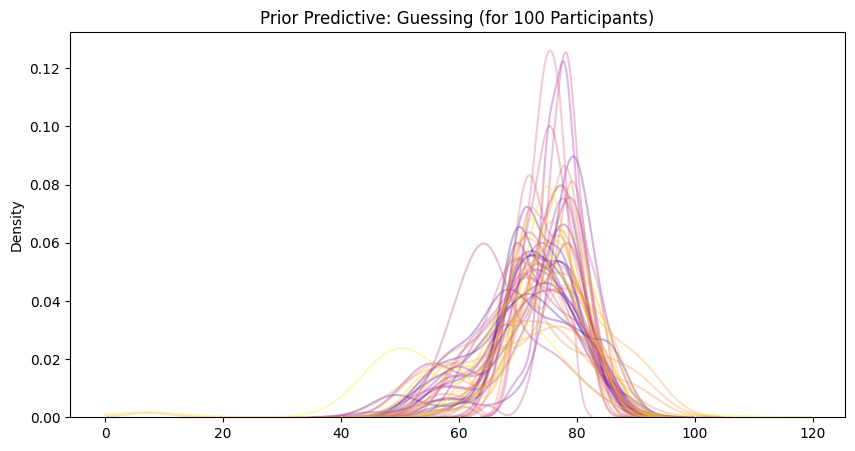

In [47]:
# Plot prior predictives
fig, axes = plt.subplots(figsize=(10, 5))
dataset_colors = sns.color_palette("plasma", n_sub).as_hex()

for dataset in range(n_sub):
    color = dataset_colors[dataset]

    sns.kdeplot(data[:,dataset].squeeze(), ax=axes, alpha=0.3, legend=False, color=color,clip=(0.0, 10000.0))
    

axes.set_title("Prior Predictive: Guessing (for 100 Participants)")

## "Fit" Models

In [46]:
# Load model if needed
# approximator  = keras.saving.load_model("..\..\Results\model_comparison_COUNTRIES.keras")

In [48]:
n_models = 6    
all_pmps = np.zeros((n_sub, n_models)) 

for i in range(n_sub):
    pmp         = approximator.predict(conditions=dict(x=data[:,i],p = position_encodings))[0]
    all_pmps[i] = pmp.flatten() 

In [49]:
# Store results
all_pmps_df  = pd.DataFrame(all_pmps)
all_pmps_df.columns = ["RULEXJ", "CAM", "GCM", "MAPP", "QEst", "RGuess"]


all_pmps_df.to_csv("..\..\Results\pmp_COUNTRIES.csv")

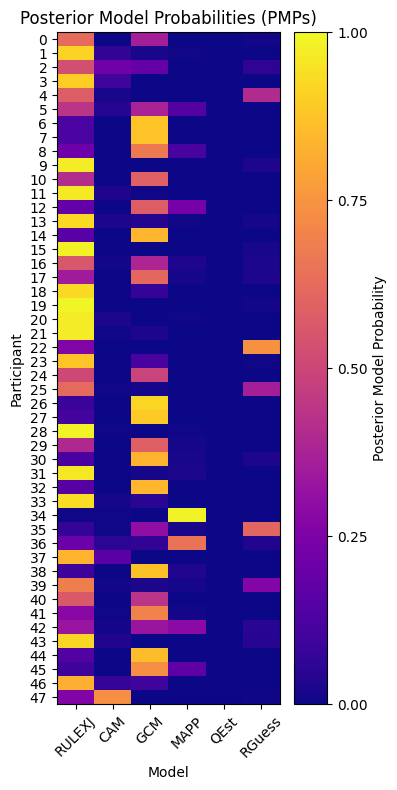

In [50]:
model_labels = ["RULEXJ", "CAM", "GCM", "MAPP", "QEst", "RGuess"]

plt.figure(figsize=(4, 8))
im = plt.imshow(all_pmps, aspect='auto', cmap='plasma', vmin=0, vmax=1)  # Fix color range

# Add colorbar with defined ticks from 0 to 1
cbar = plt.colorbar(im)
cbar.set_label('Posterior Model Probability')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])  # Explicit tick marks

plt.xlabel('Model')
plt.ylabel('Participant')
plt.title('Posterior Model Probabilities (PMPs)')

plt.xticks(ticks=np.arange(len(model_labels)), labels=model_labels, rotation=45);
plt.yticks(ticks=np.arange(n_sub), labels=[str(i) for i in range(n_sub)]);

plt.tight_layout()
plt.show()
